In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

from few.waveform import GenerateEMRIWaveform
from few.utils.constants import MTSUN_SI
from few.utils.utility import get_p_at_t
from few.utils.geodesic import get_fundamental_frequencies
from few.utils.fdutils import GetFDWaveformFromFD, GetFDWaveformFromTD
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import KerrEccEqFlux, KerrEccEqFlux_nex

from scipy.interpolate import CubicSpline
from few import get_file_manager
import tqdm

# produce sensitivity function
traj_module = EMRIInspiral(func=KerrEccEqFlux_nex, use_gpu=True)

# import ASD
data = np.loadtxt(get_file_manager().get_file("LPA.txt"), skiprows=1)
data[:, 1] = data[:, 1] ** 2
# define PSD function
get_sensitivity = CubicSpline(*data.T)

plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 12,
})

from cycler import cycler

plt.rcParams['axes.prop_cycle'] = cycler(color=[
    "#373E8E",  # black
    "#b4af1f",  # blue
    '#ff7f0e',  # orange
    '#2ca02c',  # green
    '#d62728',  # red
    '#9467bd',  # purple
    '#8c564b',  # brown
])

from mpl_toolkits.axes_grid1 import make_axes_locatable

def inner_product(x, y, psd):
    return 4 * np.real(np.sum(np.conj(x) * y / psd))

In [2]:
td_gen = GenerateEMRIWaveform(
    "FastKerrEccentricEquatorialFlux_nex",
    sum_kwargs=dict(pad_output=True, odd_len=True),
    return_list=True,
)

def wf_gen(n,e0,T,p0=None):


        # define the injection parameters
    m1 = 1e6  # central object mass (solar masses)
    a = 1-10**(-n)    # dimensionless spin parameter for the primary - will be ignored in Schwarzschild waveform
    m2 = 10.0  
    p0 = p0  
    e0 = e0  

    x0 = 1.0         # initial cos(inclination) - will be ignored in Schwarzschild waveform
    qK = np.pi / 3   # polar spin angle
    phiK = np.pi / 3 # azimuthal viewing angle
    qS = np.pi / 3   # polar sky angle
    phiS = np.pi / 3 # azimuthal viewing angle
    dist = 1.0       # luminosity distance (Gpc)

    # initial phases
    Phi_phi0 = np.pi / 3
    Phi_theta0 = 0.0
    Phi_r0 = np.pi / 3

    Tobs = T   
    dt=1


    mode_selection_threshold = 1e-4 




    waveform_kwargs = {
        "T": Tobs,
        "dt": dt,
        "mode_selection_threshold": mode_selection_threshold,
    }

   
    if p0 is None:
        p0 = get_p_at_t(
            traj_module,
            Tobs*0.99999,
            [m1, m2, a, e0, 1.0],       
            index_of_p=3,               
            index_of_a=2,               
            index_of_e=4,               
            index_of_x=5,
            traj_kwargs={},
            xtol=2e-12,                 
            rtol=8.881784197001252e-16, 
            bounds=None,
        )
        print("New p0: ", p0)



    emri_injection_params = [
        m1,
        m2,
        a,
        p0,
        e0,
        x0,
        dist,
        qS,
        phiS,
        qK,
        phiK,
        Phi_phi0,
        Phi_theta0,
        Phi_r0,
    ]


    data_channels_td = td_gen(*emri_injection_params, **waveform_kwargs) 
    time_array = np.arange(0, len(data_channels_td[0])) * dt

    return time_array, data_channels_td


def stencil(a,e,p,da):
    # define the intrinsic parameters
    m1 = 1e6  # central object mass in solar masses
    m2 = 10.0  # secondary object mass in solar masses
    p0 = p  # initial semi-latus rectum
    e0 = e  # eccentricity
    x0 = 1.0  # will be ignored in Schwarzschild waveform
    # initial phases
    Phi_phi0 = np.pi / 3
    Phi_theta0 = 0.0
    Phi_r0 = np.pi / 3
    # define the extrinsic parameters
    qK = np.pi / 3  # polar spin angle
    phiK = np.pi / 3  # azimuthal viewing angle
    qS = np.pi / 3  # polar sky angle
    phiS = np.pi / 3  # azimuthal viewing angle
    dist = 1.0  # distance in Gpc

    Tobs = 0.4  # observation time, if the inspiral is shorter, the it will be zero padded
    dt = 5.0  # time interval
    eps = 1e-2  # mode content percentage


    a0 = a
    ap2 = a0 + 2*da
    ap1 = a0 + da
    an1 = a0 - da
    an2 = a0 - 2*da

    waveform_kwargs = {"T": Tobs,"dt": dt,"mode_selection_threshold": eps}

    parametersap2 = [m1, m2, ap2, p0, e0, x0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
    parametersap1 = [m1, m2, ap1, p0, e0, x0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
    parametersan2 = [m1, m2, an2, p0, e0, x0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
    parametersan1 = [m1, m2, an1, p0, e0, x0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

    han2 = td_gen(*parametersan2, **waveform_kwargs)[0]
    hap1 = td_gen(*parametersap1, **waveform_kwargs)[0]
    han1 = td_gen(*parametersan1, **waveform_kwargs)[0]
    hap2 = td_gen(*parametersap2, **waveform_kwargs)[0]

    num = -hap2 + 8*hap1 - 8*han1 + han2
    den = 12*da

    derivitave = num/den

    time = np.arange(len(han1)) * dt

    

    return [han2,han1,hap2,hap1] , time,derivitave

In [249]:
a=1-10**(-9)
da = (1-a)*0.001
[han2,han1,hap2,hap1] , time,derivitave = stencil(a,0.2,3,da)

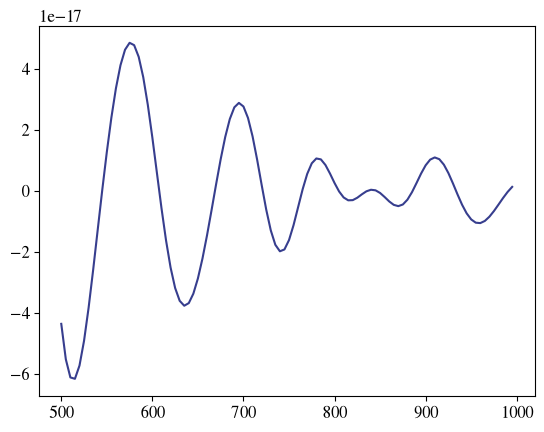

In [256]:
plt.plot(time[100:200], derivitave[100:200])

In [251]:
dt=1
#  take the FFT of the plus polarization and shift it
fft_deriv= np.fft.fftshift(np.fft.fft(derivitave)) * dt
freq = np.fft.fftshift(np.fft.fftfreq(len(derivitave), dt))

# define the positive frequencies
positive_frequency_mask = freq >= 0.0

psd = get_sensitivity(freq[positive_frequency_mask]) / np.diff(freq)[0]

In [252]:
Delta_a  = 1/np.sqrt(inner_product(fft_deriv[positive_frequency_mask],fft_deriv[positive_frequency_mask],psd))

In [253]:
Delta_a/a

np.float64(3.0754623295052765e-10)

## Detectability

In [259]:
n=9
e0=0.4
p0=3
T=0.1

data_channels_td = wf_gen(n,e0,T,p0=None)


New p0:  3.0884643525795994


In [260]:
dt=1
#  take the FFT of the plus polarization and shift it
fft_TD = np.fft.fftshift(np.fft.fft(data_channels_td[1][0])) * dt
freq = np.fft.fftshift(np.fft.fftfreq(len(data_channels_td[1][0]), dt))

# define the positive frequencies
positive_frequency_mask = freq >= 0.0



/home/james/anaconda3/envs/FEW_nexp/lib/python3.12/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/james/anaconda3/envs/FEW_nexp/lib/python3.12/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


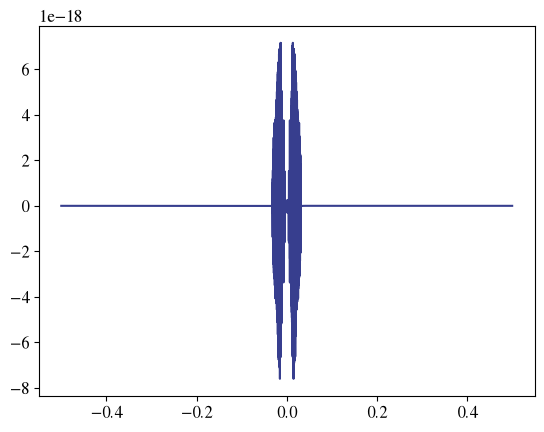

In [262]:
plt.plot(freq,fft_TD)

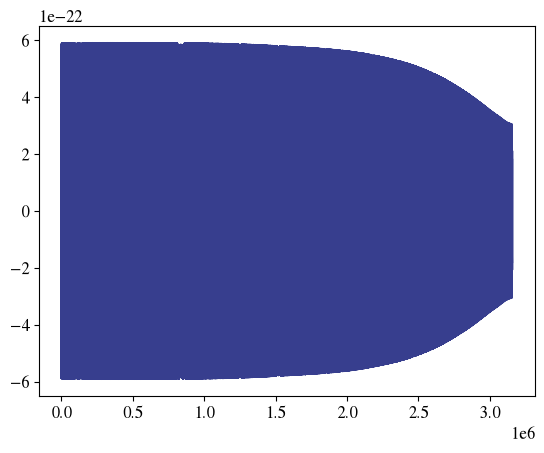

In [261]:
plt.plot(data_channels_td[0],data_channels_td[1][0])

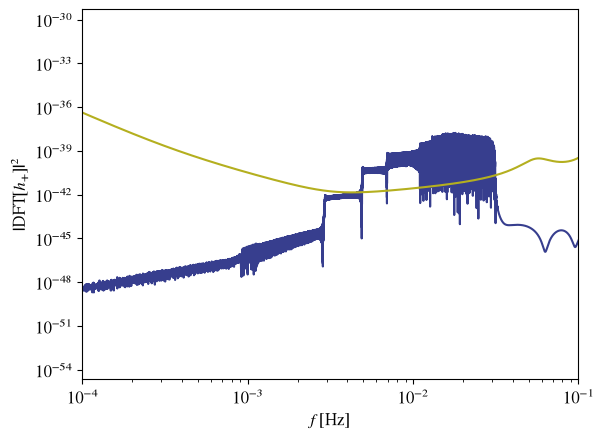

In [263]:
plt.figure()

f=freq[positive_frequency_mask]

plt.loglog(f,( f*  np.abs(fft_TD[positive_frequency_mask]) )** 2)
plt.loglog(
    f,  f*get_sensitivity(freq[positive_frequency_mask])
)

plt.ylabel(r"$| {\rm DFT} [h_{+}]|^2$")
plt.xlabel(r"$f$ [Hz]")
plt.xlim(1e-4, 1e-1)
#plt.ylim(1e-21,1e-16)
plt.show()

In [264]:
# calculate the mismatch between the FFT'd TD waveform and the direct FD waveform:
psd = get_sensitivity(freq[positive_frequency_mask]) / np.diff(freq)[0]
td_td = inner_product(
    fft_TD[positive_frequency_mask], fft_TD[positive_frequency_mask], psd
)

print("SNR", np.sqrt(td_td))

SNR 43.25550471575111


In [30]:
#https://arxiv.org/pdf/1803.01944

In [42]:
alpha, beta, kappa, gamma, fk = 0.133, 243, 482, 917, 0.00258

A=1e-6

def Poms(f):
    return ( (1.5*10**(-11))**2 ) * (1+(2*0.001/f)**4)

def Pacc(f):
    return ((3*1e-15)**2)*( 1 + (0.4*0.001/f)**2  )*(1+ (f/(8*0.001))**4)

def Sc(f):
    return A * f**(-7/3)*np.exp(-alpha + beta*f*np.sin(kappa*f)) * (1+ np.tanh(gamma*(fk-f)))

def SN(f):
    fstar = 19.09*0.001 #Hz
    L = 2.5*10**9 #m


    return (10/(3*L*L))*( Poms(f) + (4*Pacc(f))/(2*np.pi*f)**4) * ( 1+ (6/10)*(f/fstar)**2 ) #+ Sc(f)

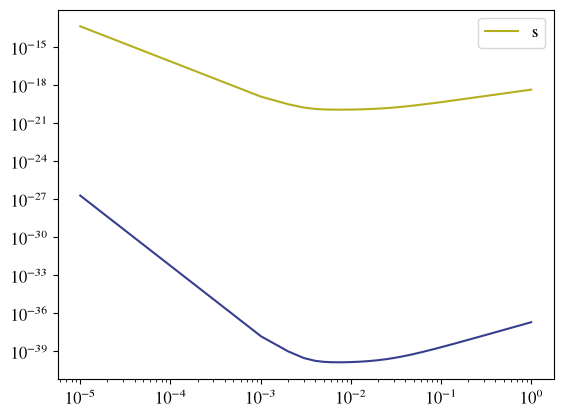

In [75]:
f= np.linspace(0.00001,1,1000)
#plt.loglog(f,Poms(f))
#plt.loglog(f,Pacc(f))
plt.loglog(f,SN(f))
plt.loglog(f,np.sqrt(Sn(f)),label ="s")
plt.legend()

In [3]:
def get_SNR(n,e0):
    #Generate a WF of length 0.1 Years, with p0 of 3 (give it p0, as most of the computation time is spent on get_p_at_t)
    T=00.9
    data_channels_td = wf_gen(n,e0,T,6)

    dt=1
    #  take the FFT of the plus polarization and shift it
    fft_TD = np.fft.fftshift(np.fft.fft(data_channels_td[1][0])) * dt
    freq = np.fft.fftshift(np.fft.fftfreq(len(data_channels_td[1][0]), dt))

    # define the positive frequencies
    positive_frequency_mask = freq >= 0.0

    psd = get_sensitivity(freq[positive_frequency_mask]) / np.diff(freq)[0]
    td_td = inner_product(
    fft_TD[positive_frequency_mask], fft_TD[positive_frequency_mask], psd
    )

    return np.sqrt(td_td)

In [ ]:
get_SNR(9,0.4)

: 

In [146]:
n_vals = np.arange(2.0,12.0,0.5)
e_vals = np.arange(0,0.45,0.05)

snrs = np.ones((len(n_vals),len(e_vals)))

for i,n in tqdm.tqdm(enumerate(n_vals)):
    for j,e in enumerate(e_vals):
        snr = get_SNR(n,e)
        snrs[i,j] *= snr

20it [17:24, 52.20s/it] 


In [147]:
snrs

array([[43.12877932, 43.07147917, 42.9671872 , 42.74752276, 42.48798745,
        42.11738499, 41.63583492, 41.04723947, 40.31817101],
       [42.88576661, 42.82707829, 42.71796053, 42.49338847, 42.22723644,
        41.8504025 , 41.36021854, 40.76233888, 40.02327866],
       [42.85058854, 42.79178631, 42.68221128, 42.45807336, 42.19159433,
        41.81325592, 41.32151571, 40.72310121, 39.98241574],
       [42.8628376 , 42.80455179, 42.69570031, 42.47222514, 42.20560737,
        41.82762924, 41.33614991, 40.73658417, 39.99437806],
       [42.87975037, 42.82221898, 42.71418765, 42.49061211, 42.22411472,
        41.8450937 , 41.35344109, 40.75333181, 40.01076576],
       [42.89153791, 42.83476771, 42.72607419, 42.50218118, 42.235081  ,
        41.85593071, 41.36361241, 40.76294276, 40.02130067],
       [42.88561018, 42.8286929 , 42.71999005, 42.49680617, 42.22996739,
        41.85150822, 41.35905743, 40.75920921, 40.01724063],
       [42.88650292, 42.8302365 , 42.72171294, 42.49828304, 42

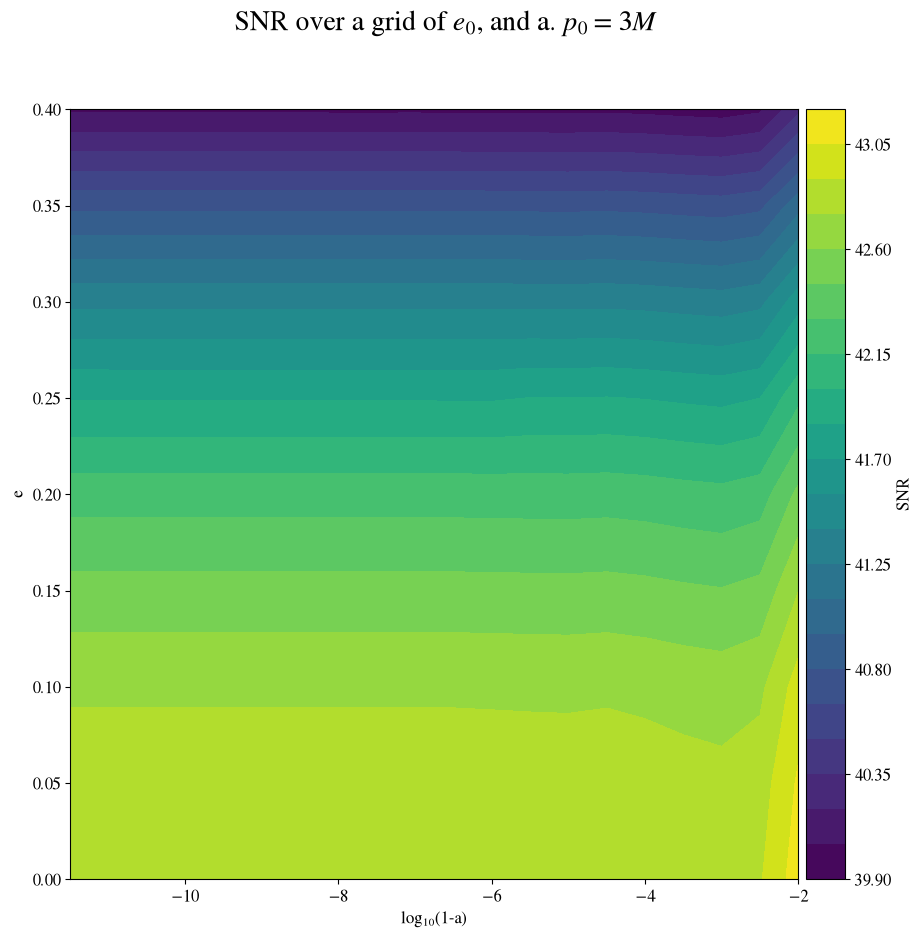

In [150]:
fig, ax = plt.subplots(1,1,figsize = (10,10))
a=1-10**(-n_vals)

N,E = np.meshgrid(-n_vals,e_vals)
Z= snrs.T

cf1 = ax.contourf(N,E,Z,  levels=30, cmap="viridis")
plt.suptitle(rf"SNR over a grid of $e_0$, and a. $p_0=3M$",fontsize =20)
fig.colorbar(cf1, ax=ax, label=r"SNR",
                pad = 0.01,orientation = "vertical", fraction=0.05)

ax.set_ylabel("e")
ax.set_xlabel(r"log$_{10}$(1-a)")

plt.show()
fig.savefig(f"contourplot_SNR_p0=3_mu=10^5_full.png", dpi=300, bbox_inches="tight")

In [117]:
a

array([0.99      , 0.999     , 0.9999    , 0.99999   , 0.999999  ,
       0.9999999 , 0.99999999, 1.        , 1.        , 1.        ])

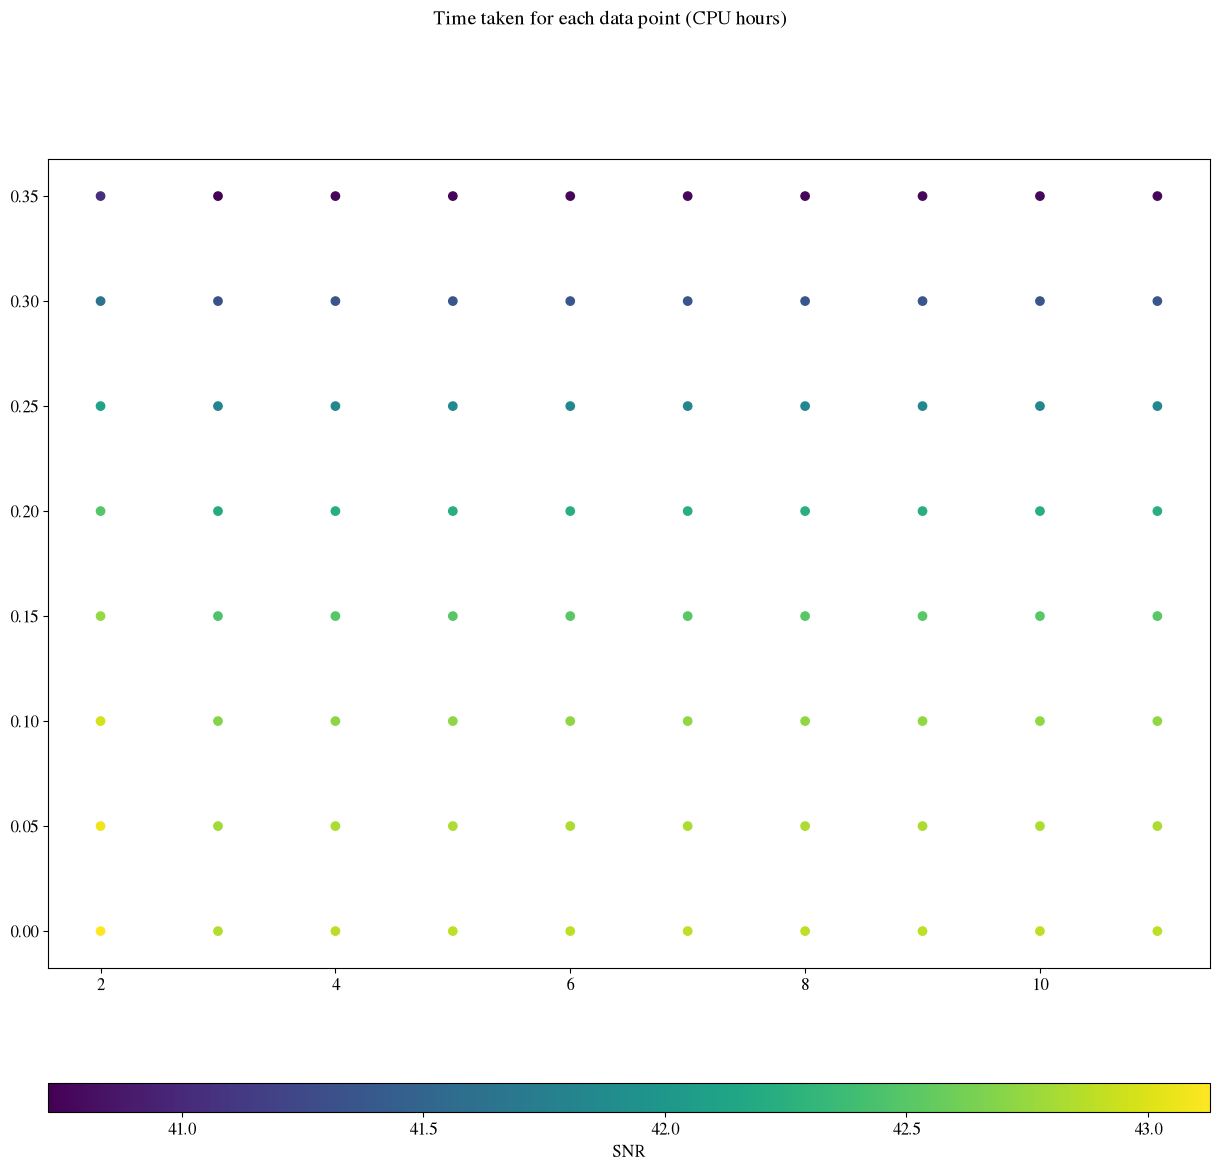

In [112]:
fig, ax = plt.subplots(1,1,figsize = (15,15))
N,E = np.meshgrid(n_vals,e_vals)
Z= snrs.T

cf1 = ax.scatter(N,E,c=Z, cmap="viridis")


plt.suptitle(rf"Time taken for each data point (CPU hours)")
fig.colorbar(cf1, ax=ax, label=r"SNR",
                pad = 0.1,orientation = "horizontal", fraction=0.2, aspect =40/1,)
plt.show()
#fig.savefig(f"contourplot_e_vs_p_n={n}_compare_with_few_ELQ.png", dpi=300, bbox_inches="tight")

In [86]:
snrs

array([[ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
       [ 0.,  2.,  4.,  6.,  8., 10., 12., 14.],
       [ 0.,  3.,  6.,  9., 12., 15., 18., 21.],
       [ 0.,  4.,  8., 12., 16., 20., 24., 28.],
       [ 0.,  5., 10., 15., 20., 25., 30., 35.],
       [ 0.,  6., 12., 18., 24., 30., 36., 42.],
       [ 0.,  7., 14., 21., 28., 35., 42., 49.],
       [ 0.,  8., 16., 24., 32., 40., 48., 56.],
       [ 0.,  9., 18., 27., 36., 45., 54., 63.]])

In [44]:
def Sn(f):
    L = 2.5e9
    f_star = 19.09e-3

    POMS = Poms(f)
    PACC = Pacc(f)

    return (
        (10 / (3 * L**2))
        * (
            POMS
            + 2 * (1 + np.cos(f / f_star)**2) * PACC / (2 * np.pi * f)**4
        )
        * (1 + 0.6 * (f / f_star)**2)
    )

In [31]:
1e-1

0.1

In [32]:
10**(-1)

0.1

## Fisher Matrix / Covariance

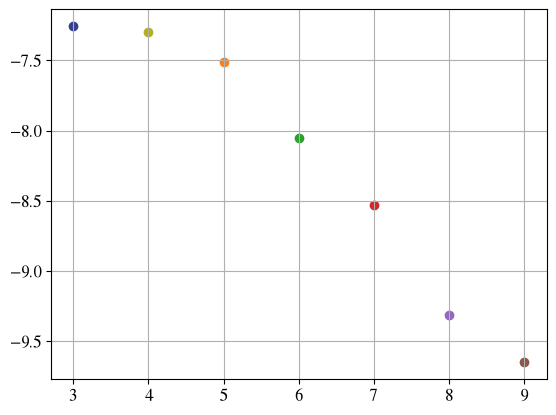

In [243]:
n_vals = [3,4,5,6,7,8,9]
for n in n_vals:
    e0=0.000
    p0=3
    a=1-10**(-n)

    da=(1-a)*1e-4

    [han2,han1,hap2,hap1] , time,derivitave = stencil(a,e0,p0,da)


    dt=5

    fft_deriv= np.fft.fftshift(np.fft.fft(derivitave)) * dt
    freq = np.fft.fftshift(np.fft.fftfreq(len(derivitave), dt))

    # define the positive frequencies
    positive_frequency_mask = freq >= 0.0

    psd = get_sensitivity(freq[positive_frequency_mask]) / np.diff(freq)[0]

    Delta_a  = 1/np.sqrt(inner_product(fft_deriv[positive_frequency_mask],fft_deriv[positive_frequency_mask],psd))

    plt.scatter(n,np.log10(Delta_a/a))
plt.grid()

In [309]:
def get_COV(n,e,p,dn):
    e0=e
    p0=p
    a=1-10**(-n)

    da=(1-a)*(10**(-dn))

    [han2,han1,hap2,hap1] , time,derivitave = stencil(a,e0,p0,da)


    dt=5

    fft_deriv= np.fft.fftshift(np.fft.fft(derivitave)) * dt
    freq = np.fft.fftshift(np.fft.fftfreq(len(derivitave), dt))

    # define the positive frequencies
    positive_frequency_mask = freq >= 0.0

    psd = get_sensitivity(freq[positive_frequency_mask]) / np.diff(freq)[0]

    Delta_a  = 1/np.sqrt(inner_product(fft_deriv[positive_frequency_mask],fft_deriv[positive_frequency_mask],psd))

    return Delta_a / a


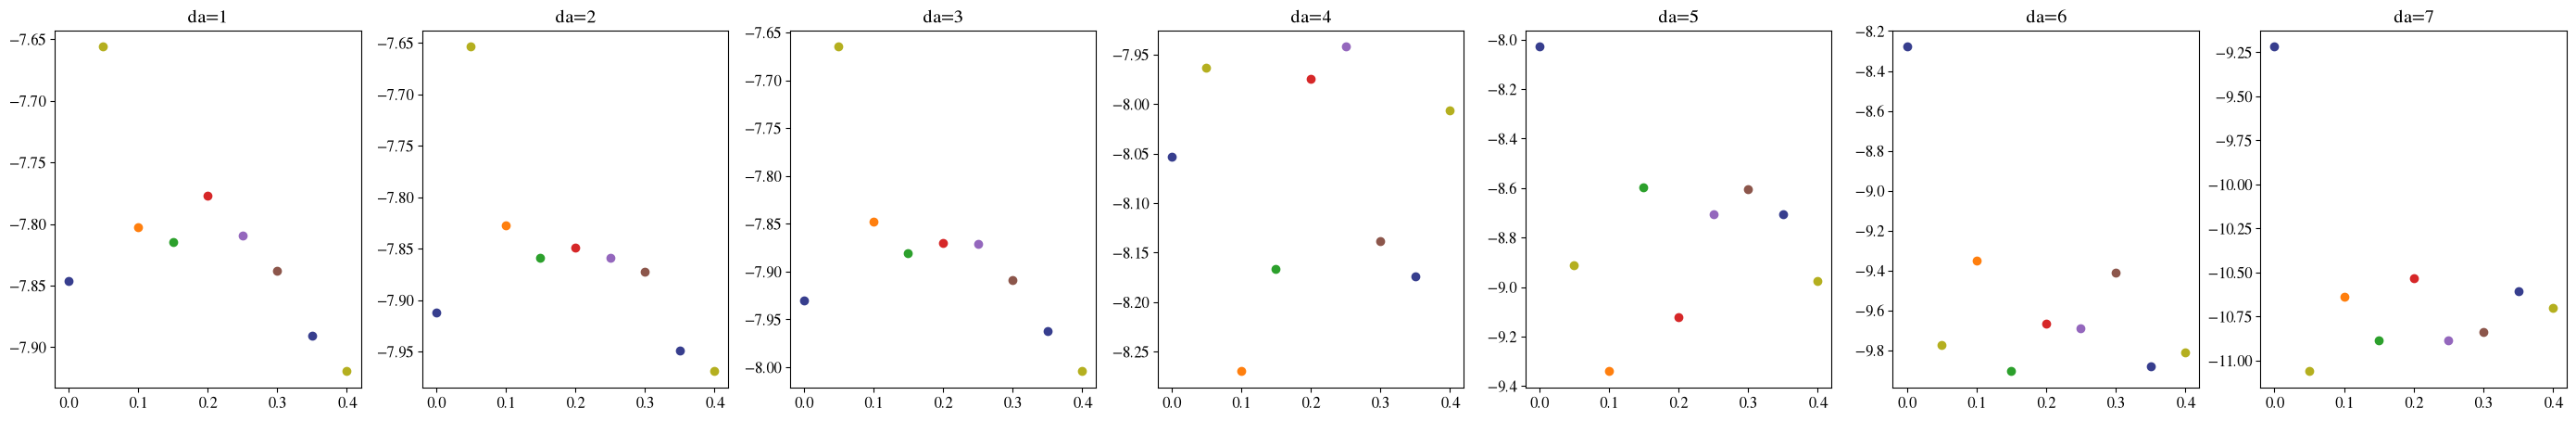

In [316]:
e_vals = np.arange(0,0.45,0.05)

das = [1,2,3,4,5,6,7]

fig,axs = plt.subplots(1,len(das),figsize = (5*len(das),5))
for ax, da in zip(axs,das):
    for e in e_vals:
        ax.scatter(e,np.log10(get_COV(6,e,3,da)))
        ax.set_title(f"da={da}")

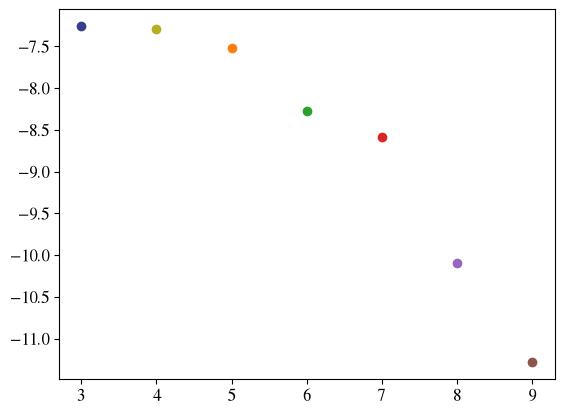

In [305]:

for n in n_vals:
    plt.scatter(n,np.log10(get_COV(n,0.0,3)))
